# PROYECTO SAMSUNG INNOVATION CAMPUS 2025-2026

## EQUIPO: THE TWO POWERPUF GIRLS AND KEVIN
### CONFORMADO POR: KEVIN LEONARDO BAÑOS SÁNCHEZ, ITZEL ALEJANDRA LESAMA APOLINAR, NORMA INÉS LLERGO SÁNCEZ

## **1.0 IMPORTACIÓN DE LIBERÍAS**

In [9]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42 #para reproducir un estado del modelo


## **2.O LEEMOS EL DATASET Y TRABAJAMOS CON SU COPIA**

In [10]:
db = pd.read_csv('diabetes2.csv')
dataset = db.copy()
dataset.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## **3.0 ANÁLISIS EXPLORATORIO DE DATOS DEL DATASET**

## EDA DEL DATASET


In [12]:
import pandas as pd
import numpy as np

# dataframe
db = pd.DataFrame({
    'age': [20, 30, np.nan, 50, 200],
    'hypertension': [0, 1, 0, 0, 1],
    'heart_disease': [1, 0, 0, 1, 0],
    'smoking_history': ['never', 'current', np.nan, 'never', 'No Info'],
    'bmi': [22.5, np.nan, 30.1, 28.0, 0],
    'HbA1c_level': [5.7, 6.6, 5.0, 4.8, 8.0],
    'blood_glucose_level': [100, 150, 80, 90, 200]
})

cols_analisis = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

print("--- RECUENTO INICIAL DE NULOS ---")
print(db[cols_analisis].isnull().sum())
print("-" * 40)

#limpieza de datos
# A. Corregir falsos nulos en BMI (el 0 no es posible físicamente)
db['bmi'] = db['bmi'].replace(0, np.nan)

# B. Imputación de valores numéricos (Usamos Mediana)
db['age'] = db['age'].fillna(db['age'].median())
db['bmi'] = db['bmi'].fillna(db['bmi'].median())

# C. Limpieza de Smoking History (aunque no la contemos al final, es bueno tenerla limpia)
db['smoking_history'] = db['smoking_history'].replace('No Info', np.nan)
db['smoking_history'] = db['smoking_history'].fillna(db['smoking_history'].mode()[0])

print("\n" + "="*45)
print("--- VERIFICACIÓN POST-LIMPIEZA (COLUMNAS CLAVE) ---")
print("="*45)

# Aquí comprobamos que todas las que pediste estén en CERO
print(db[cols_analisis].isnull().sum())

print("\n--- VISTAZO A LOS DATOS LIMPIOS ---")
print(db[cols_analisis].head())

--- RECUENTO INICIAL DE NULOS ---
age                    1
hypertension           0
heart_disease          0
bmi                    1
HbA1c_level            0
blood_glucose_level    0
dtype: int64
----------------------------------------

--- VERIFICACIÓN POST-LIMPIEZA (COLUMNAS CLAVE) ---
age                    0
hypertension           0
heart_disease          0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
dtype: int64

--- VISTAZO A LOS DATOS LIMPIOS ---
     age  hypertension  heart_disease   bmi  HbA1c_level  blood_glucose_level
0   20.0             0              1  22.5          5.7                  100
1   30.0             1              0  28.0          6.6                  150
2   40.0             0              0  30.1          5.0                   80
3   50.0             0              1  28.0          4.8                   90
4  200.0             1              0  28.0          8.0                  200


## **4.0 ENTRENAMIENTO DE MODELOS**

#### **4.1 RANDOM FOREST**

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

features = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level']
X = dataset[features]
y = dataset['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_probs = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_probs)

if 'resultados_modelos' not in globals():
    resultados_modelos = []
resultados_modelos = [m for m in resultados_modelos if m["Modelo"] != "Random Forest"]
resultados_modelos.append({"Modelo": "Random Forest", "ROC-AUC": auc_rf})

nuevo_umbral = 0.35
y_pred_ajustado = (y_probs >= nuevo_umbral).astype(int)

print(f"ROC-AUC de Random Forest: {auc_rf:.4f}")
print("Matriz de Confusión con umbral 0.35:")
print(confusion_matrix(y_test, y_pred_ajustado))

ROC-AUC de Random Forest: 0.9078
Matriz de Confusión con umbral 0.35:
[[25656  1797]
 [ 1001  1546]]


#### **4.2 KNN**

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred_ajustado, target_names=['Sin diabetes', 'Con diabetes']))

print(confusion_matrix(y_test, y_pred_ajustado)) #matriz de confusion

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_probs_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

auc_knn = roc_auc_score(y_test, y_probs_knn)
resultados_modelos.append({"Modelo": "KNN", "ROC-AUC": auc_knn})

              precision    recall  f1-score   support

Sin diabetes       0.96      0.93      0.95     27453
Con diabetes       0.46      0.61      0.52      2547

    accuracy                           0.91     30000
   macro avg       0.71      0.77      0.74     30000
weighted avg       0.92      0.91      0.91     30000

[[25656  1797]
 [ 1001  1546]]


#### **4.3 SUPPORT VECTOR MACHINE**

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

svm_features = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level']

#caracteristicas para modelo svm
X_train_svm = X_train[svm_features]
X_test_svm = X_test[svm_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_svm)
X_test_scaled = scaler.transform(X_test_svm)

modelo = SVC(kernel='linear', C=1.0)
modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)

print(f"Precisión del modelo: {accuracy_score(y_test, y_pred):.2%}")
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred, zero_division=0))

y_probs_svm = modelo.decision_function(X_test_scaled) # Probabilidades para SVM
auc_svm = roc_auc_score(y_test, y_probs_svm)
resultados_modelos.append({"Modelo": "SVM", "ROC-AUC": auc_svm})

Precisión del modelo: 94.22%

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97     27453
           1       0.99      0.32      0.49      2547

    accuracy                           0.94     30000
   macro avg       0.97      0.66      0.73     30000
weighted avg       0.95      0.94      0.93     30000



#### **4.4 LOGISTIC REGRESSION**

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
X = dataset[features]
y = dataset['diabetes']

scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train)
X_test_scaled_lr = scaler_lr.transform(X_test)

modelo = LogisticRegression(max_iter=1000) # Increased max_iter to help with convergence
modelo.fit(X_train_scaled_lr, y_train)

y_pred = modelo.predict(X_test_scaled_lr)
y_probs = modelo.predict_proba(X_test_scaled_lr)[:, 1] # Necesario para el AUC

In [20]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
sensibilidad = tp / (tp + fn)
especificidad = tn / (tn + fp)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_probs)

print(f"Accuracy:      {accuracy:.4f}")
print(f"Sensibilidad:  {sensibilidad:.4f}")
print(f"Especificidad: {especificidad:.4f}")
print(f"F1-Score:      {f1:.4f}")
print(f"AUC:           {auc:.4f}")

Accuracy:      0.9448
Sensibilidad:  0.4327
Especificidad: 0.9923
F1-Score:      0.5710
AUC:           0.9283


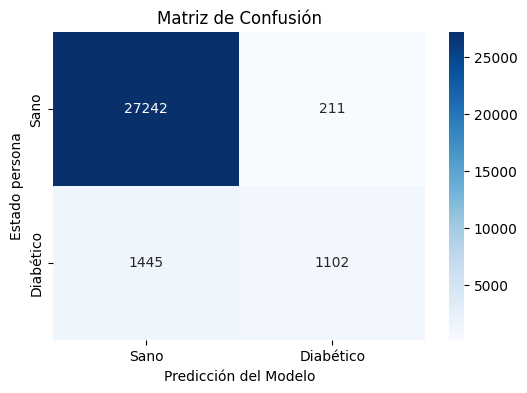

In [21]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano', 'Diabético'], yticklabels=['Sano', 'Diabético'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Estado persona')
plt.title('Matriz de Confusión')
plt.show()

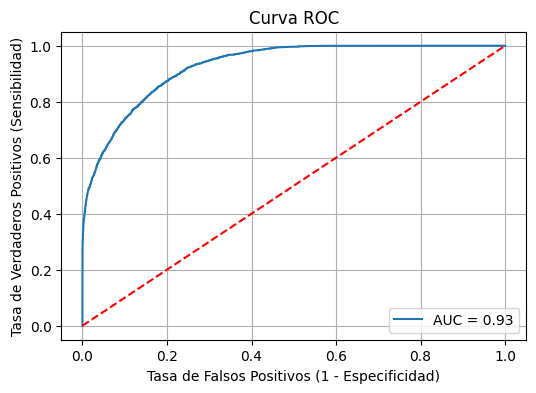

In [22]:
#CURVA ROC
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
#GRAFICACIÓN SIGMOIDE
columnas = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level','blood_glucose_level']
Y = dataset['diabetes'] # Use 'dataset' instead of 'db'

X = dataset[columnas] # Use 'dataset' instead of 'db'

modelo_lr = LogisticRegression()
modelo_lr.fit(X, Y)

Y_pred = modelo_lr.predict(X)

c:\Users\kbano\Desktop\diabetes\Diabetes-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


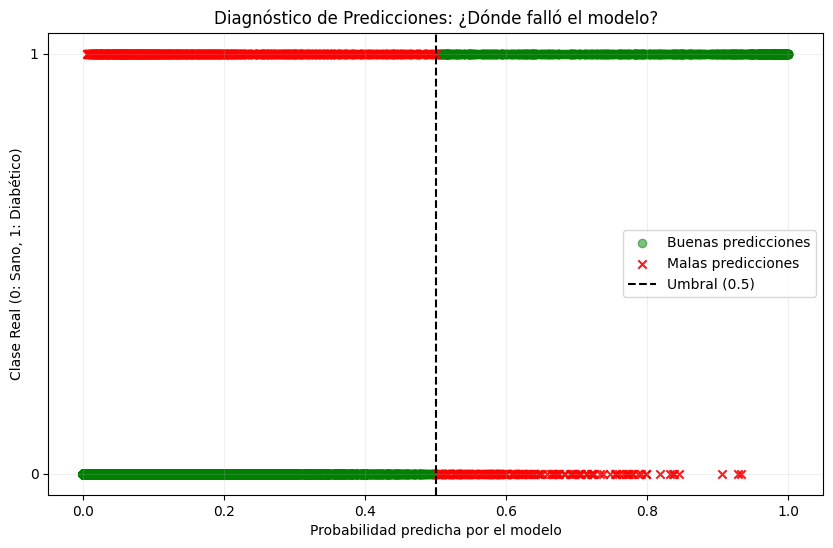

In [24]:
threshold = 0.5
y_pred = (y_probs > threshold).astype(int)

good_predictions = (y_test == y_pred)
bad_predictions = ~good_predictions

x_values = np.linspace(0, 1, 100) #poner el x_train
y_values = x_values

plt.figure(figsize=(10, 6))

plt.scatter(y_probs[good_predictions], y_test[good_predictions],
            marker='o', color='green', label='Buenas predicciones', alpha=0.5)
plt.scatter(y_probs[bad_predictions], y_test[bad_predictions],
            marker='x', color='red', label='Malas predicciones', alpha=0.9)

plt.axvline(x=threshold, color='black', linestyle='--', label=f'Umbral ({threshold})')

plt.title('Diagnóstico de Predicciones: ¿Dónde falló el modelo?')
plt.xlabel('Probabilidad predicha por el modelo')
plt.ylabel('Clase Real (0: Sano, 1: Diabético)')
plt.yticks([0, 1])
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

0.5


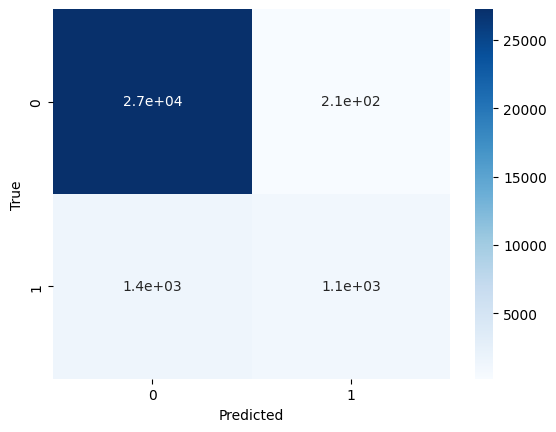

In [25]:
print(threshold)
y_pred = (y_probs > threshold).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred)

#matriz de confusión con sns
sns.heatmap(conf_matrix, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [26]:
print(classification_report(y_test, y_pred))
auc_lr = roc_auc_score(y_test, y_probs)
resultados_modelos.append({"Modelo": "Logistic Regression", "ROC-AUC": auc_lr})

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27453
           1       0.84      0.43      0.57      2547

    accuracy                           0.94     30000
   macro avg       0.89      0.71      0.77     30000
weighted avg       0.94      0.94      0.94     30000



#### **4.5 XGBOOST**

In [27]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

xgb_params = {
    'n_estimators': 600,
    'learning_rate': 0.03,
    'max_depth': 3,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'reg_lambda': 1.0,
    'objective': "binary:logistic",
    'random_state': 42,
    'n_jobs': -1
}

xgb_model = XGBClassifier(**xgb_params)

xgb_model.fit(X, y)
importancias = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importancias.head(5).index.tolist()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

score_top = cross_val_score(xgb_model, X[top_features], y, cv=cv, scoring='accuracy', n_jobs=-1).mean()
score_todas = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1).mean()

if 'resultados_modelos' not in globals():
    resultados_modelos = []

resultados_modelos.append({"Modelo": "XGBoost", "ROC-AUC": score_todas})

print(f"Top 5 Features: {top_features}")
print(f"Accuracy (Top 5): {score_top:.4f} vs Accuracy (Todas): {score_todas:.4f}")

Top 5 Features: ['HbA1c_level', 'blood_glucose_level', 'age', 'hypertension', 'heart_disease']
Accuracy (Top 5): 0.9718 vs Accuracy (Todas): 0.9722


## **5.0 COMPARACIÓN DE RESULTADOS**

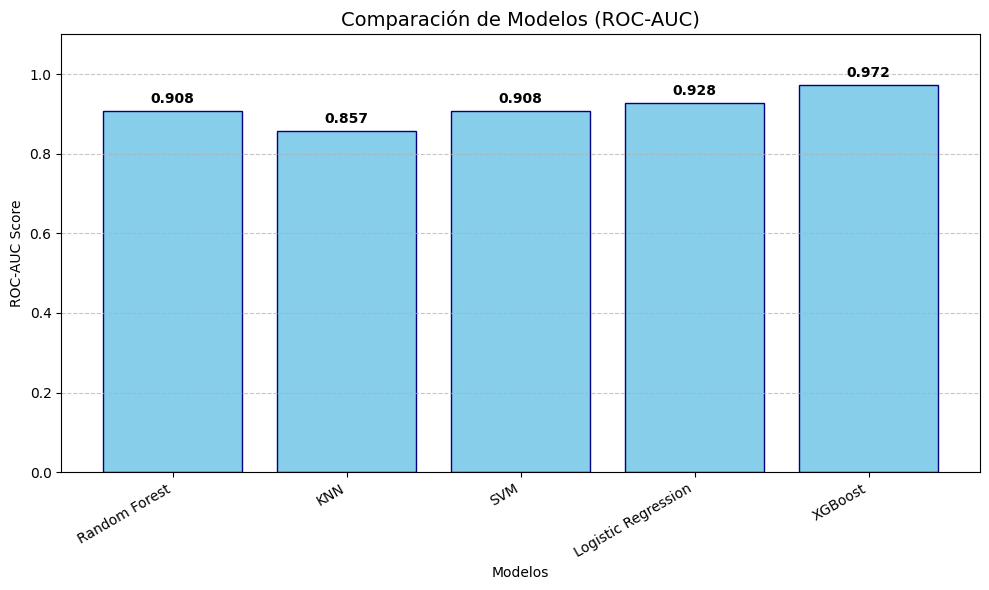

In [28]:
import matplotlib.pyplot as plt

summary_db = pd.DataFrame(resultados_modelos)

plt.figure(figsize=(10, 6))

plt.bar(summary_db["Modelo"], summary_db["ROC-AUC"], color='skyblue', edgecolor='navy')

plt.title("Comparación de Modelos (ROC-AUC)", fontsize=14)
plt.ylabel("ROC-AUC Score")
plt.xlabel("Modelos")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.1)

for i, v in enumerate(summary_db["ROC-AUC"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6.0 REALIZAMOS BÚSQUEDA HACIA ADELANTE PARA ENCONTRAR LOS MEJORES HIPERPARÁMETROS

#### 6.1 Búsqueda en modelo KNN

In [19]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.neighbors import KNeighborsClassifier

# Modelo base
model = KNeighborsClassifier() # Removed max_iter and random_state as they are not valid parameters for KNeighborsClassifier

#'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level','blood_glucose_level'

# Selección hacia adelante
sfs = SFS(model,
          k_features='best',
          forward=True,
          floating=False,
          scoring='accuracy',
          cv=5)

sfs.fit(X_train, y_train)

# Características seleccionadas
selected_features_forward = list(sfs.k_feature_names_)
print("Características seleccionadas (hacia adelante):", selected_features_forward)

Características seleccionadas (hacia adelante): ['HbA1c_level']


#### 6.2 Búsqueda en modelo de Support Vector Machine

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.svm import SVC

# Modelo base
model = SVC()
#'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level','blood_glucose_level'

# Selección hacia adelante
sfs = SFS(model,
          k_features='best',
          forward=True,
          floating=False,
          scoring='accuracy',
          cv=5)

sfs.fit(X_train, y_train)

# Características seleccionadas
selected_features_forward = list(sfs.k_feature_names_)
print("Características seleccionadas (hacia adelante):", selected_features_forward)

#### 6.3 Búsqueda en modelo de regresión logística

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression

# Modelo base
model = LogisticRegression(max_iter=500, random_state=42)

#'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level','blood_glucose_level'

# Selección hacia adelante
sfs = SFS(model,
          k_features='best',
          forward=True,
          floating=False,
          scoring='accuracy',
          cv=5)

sfs.fit(X_train, y_train)

# Características seleccionadas
selected_features_forward = list(sfs.k_feature_names_)
print("Características seleccionadas (hacia adelante):", selected_features_forward)


#### 6.4 Búsqueda en modelo de XGBOOST

In [ ]:
# Modelo base
model = XGBClassifier(max_iter=500, random_state=42)

#'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level','blood_glucose_level'

# Selección hacia adelante
sfs = SFS(model,
          k_features='best',
          forward=True,
          floating=False,
          scoring='accuracy',
          cv=5)

sfs.fit(X_train, y_train)

# Características seleccionadas
selected_features_forward = list(sfs.k_feature_names_)
print("Características seleccionadas (hacia adelante):", selected_features_forward)


## 7.0 GRID SEARCH CON LOS HIPERPARÁMETROS OBTENIDOS:
### 'age', 'hypertension', 'bmi', 'HbA1c_level'

In [ ]:
from sklearn.model_selection import train_test_split

features = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level']
X = dataset[features]
y = dataset['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#para no tener que correr lo de bsuqueda hacia adelante cada vez

#### **7.1 GRID SEARCH APLICADO EN KNN**

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

features = ['age', 'hypertension', 'bmi', 'HbA1c_level']
X = dataset[features]
y = dataset['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(classification_report(y_test, y_pred_ajustado, target_names=['Sin diabetes', 'Con diabetes']))

print(confusion_matrix(y_test, y_pred_ajustado)) #matriz de confusion

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_probs_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

auc_knn = roc_auc_score(y_test, y_probs_knn)
resultados_modelos.append({"Modelo": "KNN", "ROC-AUC": auc_knn})

NameError: name 'dataset' is not defined

#### **7.2 GRID SEARCH APLICADO EN SVM**

In [30]:
svm_features = ['age', 'hypertension', 'bmi', 'HbA1c_level']

#caracteristicas para modelo svm
X_train_svm = X_train[svm_features]
X_test_svm = X_test[svm_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_svm)
X_test_scaled = scaler.transform(X_test_svm)

modelo = SVC(kernel='linear', C=1.0)
modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)

print(f"Precisión del modelo: {accuracy_score(y_test, y_pred):.2%}")
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred, zero_division=0))

y_probs_svm = modelo.decision_function(X_test_scaled) # Probabilidades para SVM
auc_svm = roc_auc_score(y_test, y_probs_svm)
resultados_modelos.append({"Modelo": "SVM", "ROC-AUC": auc_svm})

Precisión del modelo: 94.17%

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97     27453
           1       1.00      0.31      0.48      2547

    accuracy                           0.94     30000
   macro avg       0.97      0.66      0.72     30000
weighted avg       0.94      0.94      0.93     30000



#### **7.3 GRID SEARCH APLICADO EN LOGISTIC REGRESSION**

In [31]:
scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train)
X_test_scaled_lr = scaler_lr.transform(X_test)

modelo = LogisticRegression(max_iter=1000) # Increased max_iter to help with convergence
modelo.fit(X_train_scaled_lr, y_train)

y_pred = modelo.predict(X_test_scaled_lr)
y_probs = modelo.predict_proba(X_test_scaled_lr)[:, 1] # Necesario para el AUC
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
sensibilidad = tp / (tp + fn)
especificidad = tn / (tn + fp)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_probs)

print(f"Accuracy:      {accuracy:.4f}")
print(f"Sensibilidad:  {sensibilidad:.4f}")
print(f"Especificidad: {especificidad:.4f}")
print(f"F1-Score:      {f1:.4f}")
print(f"AUC:           {auc:.4f}")

print(classification_report(y_test, y_pred))
auc_lr = roc_auc_score(y_test, y_probs)
resultados_modelos.append({"Modelo": "Logistic Regression", "ROC-AUC": auc_lr})

Accuracy:      0.9448
Sensibilidad:  0.4327
Especificidad: 0.9923
F1-Score:      0.5710
AUC:           0.9283
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27453
           1       0.84      0.43      0.57      2547

    accuracy                           0.94     30000
   macro avg       0.89      0.71      0.77     30000
weighted avg       0.94      0.94      0.94     30000



#### **7.4 GRID SEARCH APLICADO EN XGBOOST**

In [32]:
xgb_params = {
    'n_estimators': 600,
    'learning_rate': 0.03,
    'max_depth': 3,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'reg_lambda': 1.0,
    'objective': "binary:logistic",
    'random_state': 42,
    'n_jobs': -1
}

xgb_model = XGBClassifier(**xgb_params)

xgb_model.fit(X, y)
importancias = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importancias.head(4).index.tolist()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

score_top = cross_val_score(xgb_model, X[top_features], y, cv=cv, scoring='accuracy', n_jobs=-1).mean()
score_todas = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1).mean()

if 'resultados_modelos' not in globals():
    resultados_modelos = []

resultados_modelos.append({"Modelo": "XGBoost", "ROC-AUC": score_todas})

print(f"{score_todas:.4f}")

0.9543


## 8.0 SELECCIÓN DEL MEJOR MODELO

### Dada la precisión en 94% orientado a la predicción no tener diabetes y de 100% para tener diabetes en SVM, se utilizará para subir el porcentaje de precisión

### Dada la precisión en 95% orientado a la predicción no tener diabetes y de 85% para tener diabetes en LOGISTIC REGRESSION, se utilizará para subir el porcentaje de precisión

### Dada la precisión en 95% para tener o no diabetes en el modelo de XGBOOST, se utilizará para subir el porcentaje de precisión

#### **8.1 Ensamble**


In [33]:
from sklearn.ensemble import VotingClassifier

clf1 = LogisticRegression(C=0.1)
clf2 = SVC(probability=True)
clf3 = XGBClassifier()

eclf = VotingClassifier(estimators=[('lr', clf1), ('svc', clf2), ('xgb', clf3)], voting='soft')
eclf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('svc', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


#### 8.2 Guardar Modelo


In [34]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("scaler", scaler),
    ("model", eclf)
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "modelo_pipeline.pkl")

['modelo_pipeline.pkl']

In [39]:
import joblib
#cargar el modelo
model = joblib.load("modelo_pipeline.pkl")

#dato nuevo para predecir
X_new = [[50, 1, 0, 32, 7.0]]

pred = model.predict(X_new)

proba = model.predict_proba(X_new)

prediction = pred[0]
probability = proba[0][1]

print("Predicción:", prediction)
print("Probabilidad de diabetes:", probability)


Predicción: 1
Probabilidad de diabetes: 0.8270973864096299


c:\Users\kbano\Desktop\diabetes\Diabetes-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\kbano\Desktop\diabetes\Diabetes-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
